Jansen–Rit simulation

        ↓
        
Transient removal

        ↓
        
Normalization

        ↓
        
PSD estimation (Welch)

        ↓
        
Feature extraction (peaks, bands)

        ↓
        
Same analysis on real EEG

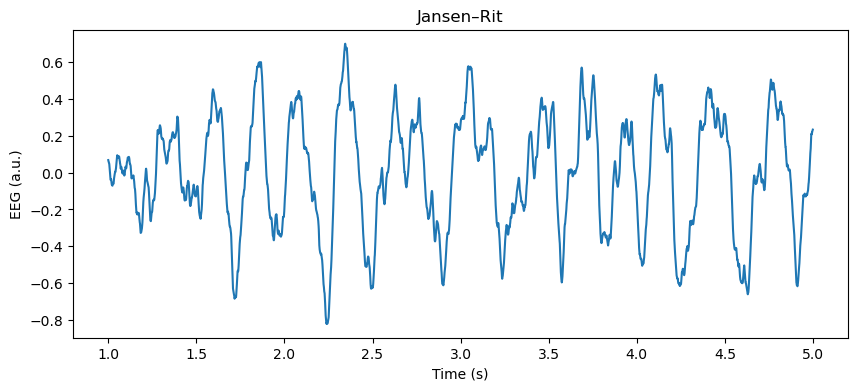

In [22]:
import numpy as np
import matplotlib.pyplot as plt


dt = 0.001
T  = 5.0
N  = int(T / dt)
time = np.arange(0, T, dt)


def sigmoid(v):
    e0 = 2.5
    v0 = 6.0
    r  = 0.56
    return (2*e0) / (1 + np.exp(r*(v0 - v)))

A=5
B = 22
a = 50; b = 25
C2 = 108; C4 = 33.75
p = 120 + 20*np.random.randn(N)



y_e  = np.zeros(N); z_e  = np.zeros(N)
y_i  = np.zeros(N); z_i  = np.zeros(N)
y_pe = np.zeros(N); z_pe = np.zeros(N)
y_pi = np.zeros(N); z_pi = np.zeros(N)

v_p  = np.zeros(N)


for i in range(N-1):

    v_p[i] = y_pe[i] - y_pi[i]

    r_p = sigmoid(v_p[i])
    r_e = sigmoid(y_e[i])
    r_i = sigmoid(y_i[i])

    # Excitatory interneuron
    y_e[i+1] = y_e[i] + dt*z_e[i]
    z_e[i+1] = z_e[i] + dt*(A*a*r_p - 2*a*z_e[i] - a*a*y_e[i])

    # Inhibitory interneuron
    y_i[i+1] = y_i[i] + dt*z_i[i]
    z_i[i+1] = z_i[i] + dt*(B*b*r_p - 2*b*z_i[i] - b*b*y_i[i])

    # Pyramidal excitatory
    y_pe[i+1] = y_pe[i] + dt*z_pe[i]
    z_pe[i+1] = z_pe[i] + dt*(A*a*(p[i] + C2*r_e) - 2*a*z_pe[i] - a*a*y_pe[i])

    # Pyramidal inhibitory
    y_pi[i+1] = y_pi[i] + dt*z_pi[i]
    z_pi[i+1] = z_pi[i] + dt*(B*b*(C4*r_i) - 2*b*z_pi[i] - b*b*y_pi[i])

EEG = y_pe - y_pi

start = int(1.0 / dt)

EEG = EEG[start:]
EEG = EEG - np.mean(EEG)

time = time[start:]


plt.figure(figsize=(10,4))
plt.plot(time, EEG)
plt.title("Jansen–Rit")
plt.xlabel("Time (s)")
plt.ylabel("EEG (a.u.)")
plt.show()

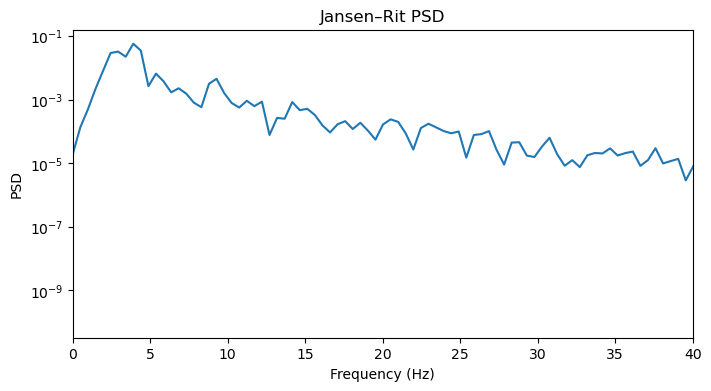

In [23]:
from scipy.signal import welch

fs = int(1/dt)

freqs, psd_model = welch(
    EEG,
    fs=fs,
    nperseg=2048
)

plt.figure(figsize=(8,4))
plt.semilogy(freqs, psd_model)
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Jansen–Rit PSD")
plt.show()


In [24]:
import mne
from scipy.signal import welch

In [25]:
# Load PhysioNet EEG Motor Imagery data
subject = 1
run = 4  # motor imagery run

paths = mne.datasets.eegbci.load_data(subject, [run])
raw = mne.io.read_raw_edf(paths[0], preload=True)

# Standardize channel names
mne.datasets.eegbci.standardize(raw)

# Set standard montage (important for EEG sanity)
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# Band-pass filter (same philosophy as model preprocessing)
raw.filter(1., 40., fir_design="firwin")


Extracting EDF parameters from C:\Users\bartu\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.9 MiB, data loaded>

In [26]:
channel = "O1"   # or "C3"
fs_eeg = int(raw.info["sfreq"])

# Extract EEG data (shape: [n_channels, n_times])
eeg_data = raw.copy().pick_channels([channel]).get_data()[0]

# Preprocess to match model assumptions
eeg_data = eeg_data - np.mean(eeg_data)
eeg_data = eeg_data / np.std(eeg_data)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


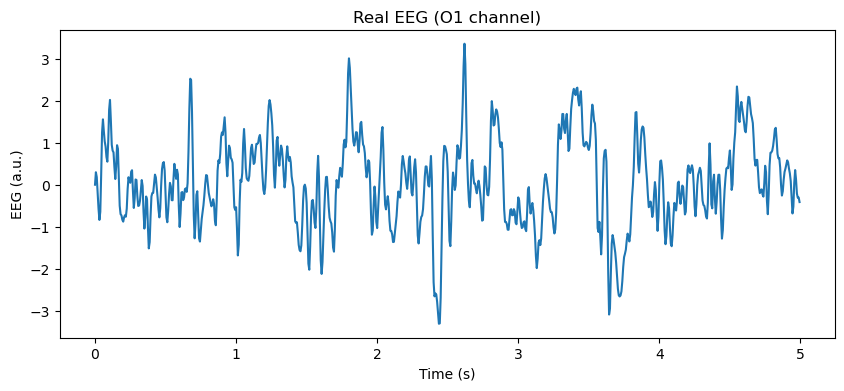

In [31]:
duration = 5  # seconds
n_samples = int(duration * fs)

t = np.arange(n_samples) / fs

plt.figure(figsize=(10,4))
plt.plot(t, eeg_data[:n_samples])
plt.xlabel("Time (s)")
plt.ylabel("EEG (a.u.)")
plt.title("Real EEG (O1 channel)")
plt.show()



In [32]:
freqs_eeg, psd_eeg = welch(
    eeg_data,
    fs=fs_eeg,
    nperseg=2048
)


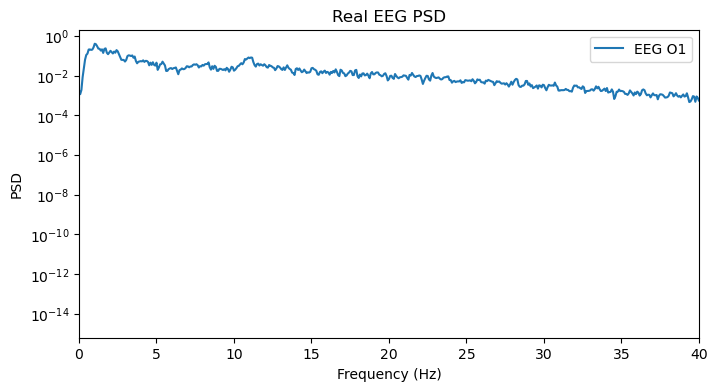

In [33]:
plt.figure(figsize=(8,4))
plt.semilogy(freqs_eeg, psd_eeg, label=f"EEG {channel}")
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Real EEG PSD")
plt.legend()
plt.show()


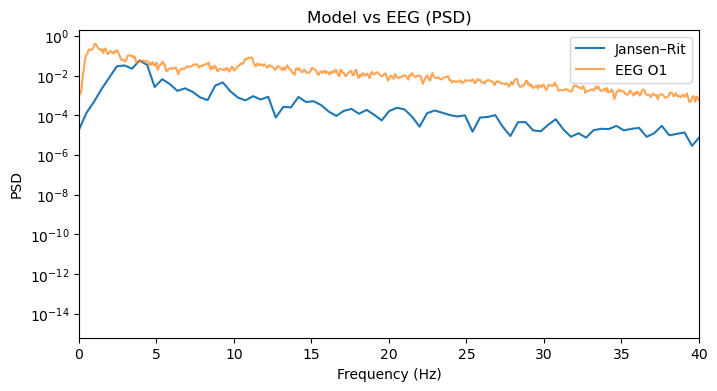

In [34]:
plt.figure(figsize=(8,4))
plt.semilogy(freqs, psd_model, label="Jansen–Rit")
plt.semilogy(freqs_eeg, psd_eeg, label=f"EEG {channel}", alpha=0.7)
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.legend()
plt.title("Model vs EEG (PSD)")
plt.show()


A simple neural mass model reproduces low-frequency-dominated spectral structure similar to EEG, but lacks the broadband 1/f background observed in real data.

we saw that:

Jansen–Rit → produces  (relatively)structured oscillations

Real EEG → oscillations on top of a broadband background


EEG PSD ≈ aperiodic background (1/fᵏ) + periodic oscillatory peaks

lets

estimate background

remove it

compare peaks

In [35]:
log_freqs = np.log10(freqs[1:])        # skip 0 Hz
log_psd_model = np.log10(psd_model[1:])
log_psd_eeg   = np.log10(psd_eeg[1:])


In [42]:
bg_mask = (freqs[1:] >= 20) & (freqs[1:] <= 40)


# Linear fit: log(PSD) = c - k log(f)
k_model, c_model = np.polyfit(
    log_freqs[bg_mask],
    log_psd_model[bg_mask],
    1
)

k_eeg, c_eeg = np.polyfit(
    log_freqs[bg_mask],
    log_psd_eeg[bg_mask],
    1
)


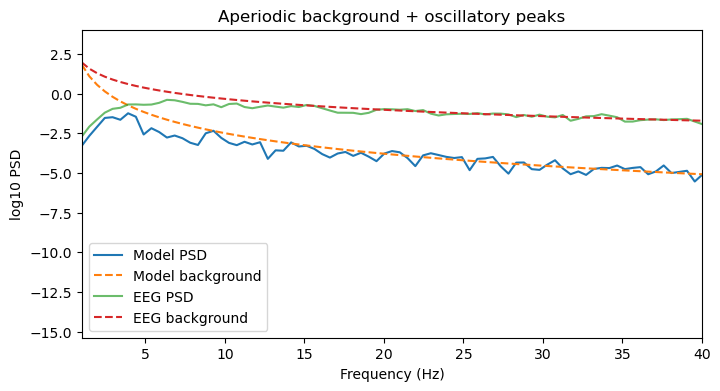

In [43]:
bg_model = c_model + k_model * log_freqs
bg_eeg   = c_eeg   + k_eeg   * log_freqs

plt.figure(figsize=(8,4))
plt.plot(freqs[1:], log_psd_model, label="Model PSD")
plt.plot(freqs[1:], bg_model, '--', label="Model background")

plt.plot(freqs[1:], log_psd_eeg, label="EEG PSD", alpha=0.7)
plt.plot(freqs[1:], bg_eeg, '--', label="EEG background")

plt.xlim(1, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("log10 PSD")
plt.legend()
plt.title("Aperiodic background + oscillatory peaks")
plt.show()


In [44]:
osc_model = log_psd_model - bg_model
osc_eeg   = log_psd_eeg   - bg_eeg


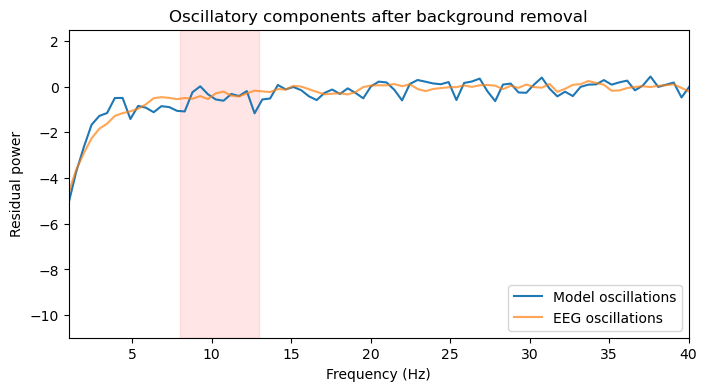

In [45]:
plt.figure(figsize=(8,4))
plt.plot(freqs[1:], osc_model, label="Model oscillations")
plt.plot(freqs[1:], osc_eeg, label="EEG oscillations", alpha=0.7)
plt.axvspan(8, 13, color='red', alpha=0.1)
plt.xlim(1, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Residual power")
plt.legend()
plt.title("Oscillatory components after background removal")
plt.show()


After removing the aperiodic background, both model and EEG show small residual oscillatory components. The EEG residual is smoother due to spatial and temporal averaging, while the neural mass model exhibits more variability due to its low dimensionality. In this motor imagery dataset, no strong alpha excess is observed, consistent with task-related alpha suppression.